In [2]:
%matplotlib inline
from pathlib import Path
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.backends.backend_pdf
import matplotlib.style as mplstyle
import os
from datetime import datetime
import matplotlib.colors as mcolors

In [3]:
from hole_trajectory import calculate_trajectory_3d, plot_trajectory_3d, calc_binned_angles, plot_stability_comparison, calc_inclination, plot_inclination

In [4]:
mplstyle.use('fast')
plt.rcParams['lines.markersize'] = 1
plt.rcParams['font.size'] = 14
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['image.cmap'] = "viridis"
plt.rcParams['figure.max_open_warning'] = 50

In [5]:
# Publication-quality settings for this figure
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [6]:
from multi_log_reader import MultiLogReader
from preprocess import preprocess
#folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID Documents/Season Reports/2025/DataLog" 


In [7]:
# Step cutters vs flat cutters
# Site 14, Hole 5  - got stuck 
folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/" 
start_date="20240625"
end_date="20240626"
print(folder)

#if out_file is None:
#    end_date_str = ""
#    if end_date is not None:
#        end_date_str = f"_{end_date}"
#    out_file = Path(f"BigRAID_{start_date}{end_date_str}.pdf")
#out_file = Path(out_file)
#out_file = out_file.with_name(out_file.name.replace(":", "-"))
#print(out_file)

mr = MultiLogReader.find_files(folder, start_date, end_date)
df = mr.as_df()
df = preprocess(df, run_depth_threshold=1.5)
#_plot(df, out_file)

/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/
Error decoding record: err='unpack requires a buffer of 38 bytes', raw='b''', sep='b' ''


GridSpec(1, 2, width_ratios=[0.8, 2])


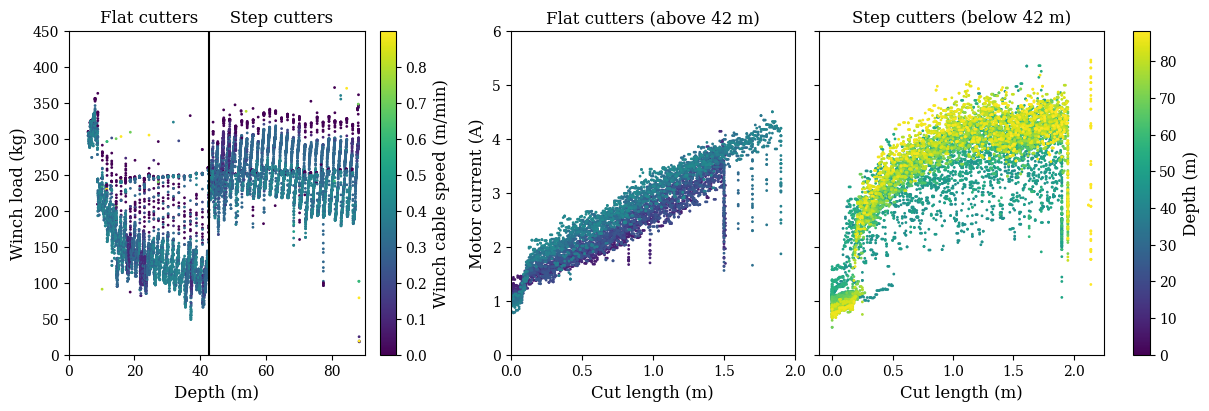

In [23]:
global_min = np.min(df["[PLC]WIRESPOOLEDOUT"])
global_max = np.max(df["[PLC]WIRESPOOLEDOUT"])
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)


fig = plt.figure(figsize=(12, 4))
outer_grid = fig.add_gridspec(1, 2, width_ratios=[0.8,2], wspace=0.05)
axes={}

print(outer_grid)
# Split the left section into two columns that share a Y-axis
left_grid = outer_grid[1].subgridspec(1, 2, wspace=-0.1)
axes[0] = fig.add_subplot(left_grid[0])
axes[1] = fig.add_subplot(left_grid[1],  sharey=axes[0])
# Create the independent right plot
axes[2] = fig.add_subplot(outer_grid[0])

# Plots 1 & 2: Shared color limits (vmin/vmax) and shared y-axis
im1=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] < 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = axes[0], norm = norm, colorbar=False)
im2=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"]>= 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = axes[1], norm = norm, colorbar=False)
# Single colorbar for the first two plots
fig.colorbar(im1.collections[0], ax=[axes[0], axes[1]], orientation='vertical', shrink=1, location='right', label= 'Depth (m)')

axes[0].set_xlabel("Cut length (m)")
axes[0].set_ylabel("Motor current (A)")
axes[0].set_ylim(0,6)
axes[0].set_xlim(0,2)
axes[0].set_title('Flat cutters (above 42 m)')
axes[1].set_title('Step cutters (below 42 m)')
axes[1].set_xlabel("Cut length (m)")


# Plot 3: Independent axes and colorbar
im3 = df[(df["cutting"] == 1)].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED", s =1, rasterized=True, cmap="viridis", ax = axes[2], colorbar = False)
axes[2].set_xlabel("Depth (m)")
axes[2].set_ylabel("Winch load (kg)")
axes[2].vlines(42.5, ymin = 0, ymax = 450, color = 'k')#, color = 'k')
#ax.text(10,400,"flat cutters")
#ax.text(50,400,"step cutters")
axes[2].set_title("Flat cutters      Step cutters")
axes[2].set_ylim(0,450)
axes[2].set_xlim(0,90)

# Re-enable y-ticks if sharey=True disabled them for the 3rd plot
axes[2].yaxis.set_tick_params(labelleft=True) 
fig.colorbar(im3.collections[0], ax=axes[2], orientation='vertical', shrink=1, location='right', label= 'Winch cable speed (m/min)')
#plt.tight_layout()
plt.savefig("paper_plots/step_vs_flat.pdf")


In [20]:
label = {}
dataset = {}
color = {}
marker = {}
# Hole 15 #1 (the last hole of 2024)
folder2024 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/" 
start_date="20240703"
end_date="20240726"
dataset[1] = MultiLogReader.find_files(folder2024, start_date, end_date).as_df()
#df1 = mr1.as_df()
dataset[1] = preprocess(dataset[1], run_depth_threshold=1.5)

# folder2025 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2025/DataLog/" 
# start_date="20250614"
# end_date="20250618"
# mr2 = MultiLogReader.find_files(folder2025, start_date, end_date)
# df2 = mr2.as_df()
# df2 = preprocess(df2, run_depth_threshold=1.5)

# Site 15 #2 (the first done in 2025)
folder2025 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2025/DataLog/" 
start_date="20250614"
end_date="20250618"
dataset[2] = MultiLogReader.find_files(folder2025, start_date, end_date).as_df()
#df2 = mr2.as_df()
dataset[2] = preprocess(dataset[2], run_depth_threshold=1.5)

# Site 35 #1
start_date="20250623"
end_date="20250625T12:00:00"
dataset[3] = MultiLogReader.find_files(folder2025, start_date, end_date).as_df()
#df3 = mr3.as_df()
dataset[3] = preprocess(dataset[3], run_depth_threshold=1.5)

Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error deco

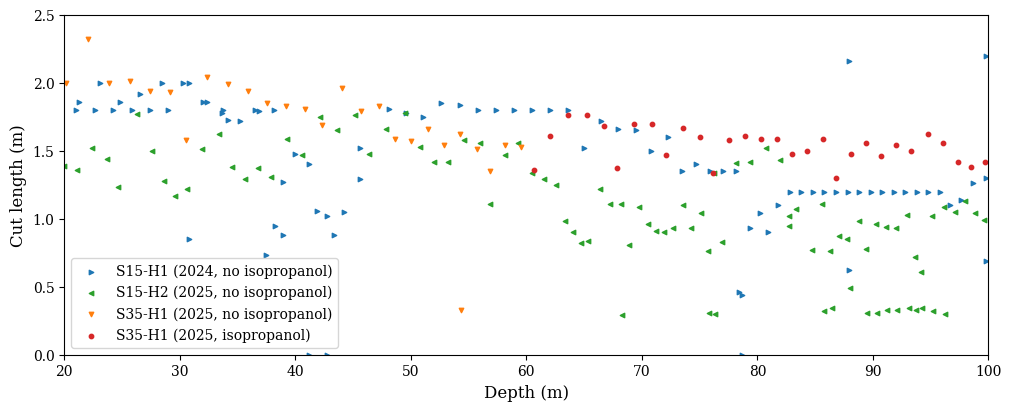

In [21]:
fig = plt.figure()
fig.set_figwidth(10)
fig.set_figheight(4)
ax = plt.subplot()
label[1]= 'S15-H1 (2024, no isopropanol)'
color[1]='tab:blue'
marker[1]='>'
label[2]= 'S15-H2 (2025, no isopropanol)'
color[2]='tab:green'
marker[2]='<'
label[3]= 'S35-H1 (2025, no isopropanol)'
color[3]='tab:orange'
marker[3]='v'
label[4]= 'S35-H1 (2025, isopropanol)'
color[4]='tab:red'
marker[4]='o'

for i in range(1,4):
    d = dataset[i]
    run = d['run'].groupby(d['run']).max()
    run_cut_depth = d['cut_depth'].groupby(d['run']).max()
    run_stop_depth = d["[PLC]AUTODOWNSTOPDEPTH"].groupby(d['run']).max()
    if i==3:
        ax.scatter(run_stop_depth.values[run_stop_depth.values<=60.6], run_cut_depth.values[run_stop_depth.values<=60.6], color = color[i], marker = marker[i],s = 10,label = label[i], alpha = 1)
        ax.scatter(run_stop_depth.values[run_stop_depth.values>60.6], run_cut_depth.values[run_stop_depth.values>60.6],color = color[i+1], marker = marker[i+1],s = 10,label = label[i+1], alpha = 1)

    else:
        ax.scatter(run_stop_depth.values, run_cut_depth.values, color = color[i], marker = marker[i],s = 10,label = label[i], alpha = 1)
ax.legend(loc = 3)
ax.set_ylabel("Cut length (m)")
ax.set_xlabel("Depth (m)")
ax.set_xlim(20,100)
ax.set_ylim(0,2.5)
fig.savefig("paper_plots/isopropanol_effect.pdf")

# fig = plt.figure()
# fig.set_figwidth(10)
# fig.set_figheight(5)

# ax = plt.subplot()
# for i in range(1,4):
#     d = dataset[i]
#     run = d['run'].groupby(d['run']).max()
#     run_cut_depth = d['cut_depth'].groupby(d['run']).max()
#     run_stop_depth = d["[PLC]AUTODOWNSTOPDEPTH"].groupby(d['run']).max()
#     ax.bar(run.values+0.3*(i-1), run_cut_depth.values, label = label[i], alpha = 1, width=0.3)
# #ax.bar(run2.values, run_cut_depth2.values, label = "S15 H2 (2025) (no isopropanol)", alpha = 0.5,width=0.5)
# #ax.bar(run3.values, run_cut_depth3.values, label = "S35 H1 (2025) (isopropanol)", alpha = 0.5,width=0.5)
# ax.legend(loc = 3)
# ax.set_xlim(30,100)
# ax.set_ylabel("Cut length (m)")
# ax.set_xlabel("Run")
# ax.set_ylim(0,2.5)

In [10]:
import json
import pandas as pd
folder = folder2025
hole_times = "2025-Drill-Log.json"

with Path(hole_times).open("r") as f:
    hole_time_data = json.load(f)

dataframes = []
for hole_data in hole_time_data:
    try:
        number, site, hole, t_start, t_end, geoloc = (
            hole_data['number'],
            hole_data['site'], hole_data['hole'],
            hole_data['start'], hole_data.get('end'),
            hole_data.get('geoloc', "")
        )
    except KeyError as e:
        print(f"Error. Malformed hole times json. Missing: {e} in {hole_data}")
        continue

    print(f"Reading data for hole {number}-{site}-{hole}", t_start, t_end)
    cached_df = MultiLogReader.find_files(folder, t_start, t_end).as_df()
    cached_df = preprocess(cached_df)
    cached_df['number'] = number
    cached_df['site'] = site
    cached_df['hole'] = hole
    cached_df['geoloc'] = geoloc

    cached_df['hole_duration'] = np.arange(0, cached_df.shape[0])

    dataframes.append(cached_df)

mdf = pd.concat(dataframes)

Reading data for hole 2-25-1 2025-06-04 2025-06-06
Reading data for hole 3-25-2 2025-06-07 2025-06-10T14:00:00
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error dec

In [11]:
# multi hole duration plot (black-and-white, journal style)

from matplotlib.dates import DateFormatter


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12

hole_groups = mdf.groupby(['number','site', 'hole'])

# Assign three shades of the same base color per site
sites = sorted(mdf['site'].unique())
#base_colors = plt.cm.tab10.colors[:len(sites)]
###595959
base_colors = ((0, 0x6B/0xFF, 0xA4/0xFF, 1.0),
               (0xFF/0xFF, 0x80/0xFF, 0x0E/0xFF, 1.0),
               (0xAB/0xFF, 0xAB/0xFF, 0xAB/0xFF, 1.0),
               (0x59/0xFF, 0x59/0xFF, 0x59/0xFF, 1.0),
)

base_colors = ((0xe6/0xff, 0x9d/0xFF, 0x00/0xFF, 1.0),
               (0x56/0xFF, 0xb3/0xFF, 0xe9/0xFF, 1.0),
               #(0x00/0xFF, 0x9e/0xFF, 0x74/0xFF, 1.0),
               (0.4,0.4,0.4,1.0),
               #(0xf0/0xFF, 0xe4/0xFF, 0x42/0xFF, 1.0),
               (0xcc/0xff, 0x7b/0xff, 0xa8/0xff, 1.0)
)
site_shades = {}
for s, base in zip(sites, base_colors):
    # Generate three shades: 100%, 65%, and 35% of the base color
    site_shades[s] = [
        (base[0],  base[1],  base[2], 1.0),
        (base[0],  base[1],  base[2], 0.75),
        (base[0],  base[1],  base[2], 0.5),
    ]
    print(s, base, site_shades[s])
    # site_shades[s] = [
    #     (base[0]*1.0,  base[1]*1.0,  base[2]*1.0, 1.0),
    #     (base[0]*0.65, base[1]*0.65, base[2]*0.65, 1.0),
    #     (base[0]*0.35, base[1]*0.35, base[2]*0.35, 1.0),
    # ]


15 (0.9019607843137255, 0.615686274509804, 0.0, 1.0) [(0.9019607843137255, 0.615686274509804, 0.0, 1.0), (0.9019607843137255, 0.615686274509804, 0.0, 0.75), (0.9019607843137255, 0.615686274509804, 0.0, 0.5)]
25 (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 1.0) [(0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 1.0), (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 0.75), (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 0.5)]
34 (0.4, 0.4, 0.4, 1.0) [(0.4, 0.4, 0.4, 1.0), (0.4, 0.4, 0.4, 0.75), (0.4, 0.4, 0.4, 0.5)]
35 (0.8, 0.4823529411764706, 0.6588235294117647, 1.0) [(0.8, 0.4823529411764706, 0.6588235294117647, 1.0), (0.8, 0.4823529411764706, 0.6588235294117647, 0.75), (0.8, 0.4823529411764706, 0.6588235294117647, 0.5)]


/var/folders/zc/gr8l7sm14cz6lm7fbm335cx80000gr/T/ipykernel_26113/2989628089.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/zc/gr8l7sm14cz6lm7fbm335cx80000gr/T/ipykernel_26113/2989628089.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


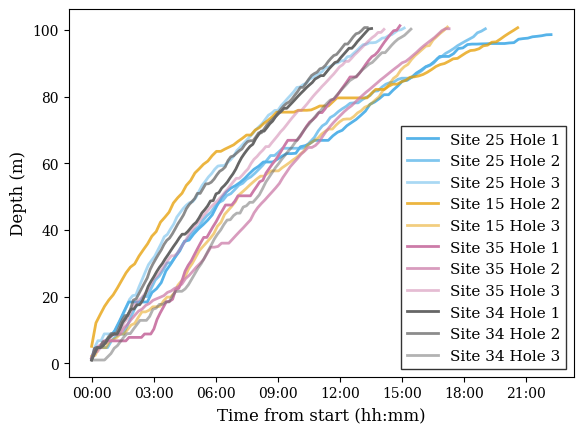

In [12]:
# Hole -> shade index within a site (1->0, 2->1, 3->2, 4->0, ...)
fig = plt.figure(figsize=(6, 4.5))
ax = fig.subplots()

for spine in ax.spines.values():
    spine.set_color('black')
ax.tick_params(axis='both', colors='black')


for (number, site, hole), idx in hole_groups.groups.items():
    data = mdf.loc[idx, ['[PLC]WIRESPOOLEDOUT', 'hole_duration']].cummax()
    # Choose 100 evenly spaced points and subsample the data
    subset_idx = np.round(np.linspace(0, data.shape[0]-1, 100)).astype(int)
    subsample = data.iloc[subset_idx]

    shade_idx = (int(hole) - 1) % 3
    color = site_shades[site][shade_idx]
    
    ax.plot(
        pd.to_datetime(subsample['hole_duration'], unit='s'),
        subsample['[PLC]WIRESPOOLEDOUT'],
        color=color,
        linewidth=2,
        label=f"Site {site} Hole {hole}",
    )

formatter = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel("Time from start (hh:mm)")
ax.set_ylabel("Depth (m)")
ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='black', fontsize=11)
fig.tight_layout()
fig.savefig("paper_plots/performance-2025.pdf")
fig.show()

In [13]:
df.keys()

Index(['[PLC]AUTODOWNSTOPDEPTH', '[PLC]AUTOMODE', '[PLC]AUTOSEQ',
       '[PLC]CABLESPEED', '[PLC]CABLETENSION', '[PLC]CABLETENSIONGRAMS',
       '[PLC]DRILLACTIVECURRENT', '[PLC]DRILLFEEDBACKVEL', '[PLC]DRILLTEMP',
       '[PLC]ICECONVEYOR.SETSPEED', '[PLC]IMUPITCH',
       '[PLC]IMUPITCHRATEFILTERED', '[PLC]IMUROLL', '[PLC]IMUROLLRATEFILTERED',
       '[PLC]IMUYAW', '[PLC]IMUYAWRATEFILTERED', '[PLC]SNOWBLOWER.ACTUALRPM',
       '[PLC]WIRESPOOLEDOUT', 'run', 'cutting', 'cut_depth', 'weight_on_bit',
       'hole_pitch', 'hole_roll'],
      dtype='object', name='tag')

{1: 'S15-H1 (2024, no isopropanol)', 2: 'S15-H2 (2025, no isopropanol)', 3: 'S35-H1 (2025, isopropanol)'}
S15-H1 (2024)


/Users/delia/Library/CloudStorage/OneDrive-UW-Madison/RNO-G/data_analysis/git/bigraid_log_reader/hole_trajectory.py:180: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


0 Axes3D(0.01,0.0718685;0.472792x0.784961)
1 Axes(0.517208,0.51304;0.472792x0.343789)
2 Axes(0.517208,0.0718685;0.472792x0.343789)
S35-H1 (2025)


/Users/delia/Library/CloudStorage/OneDrive-UW-Madison/RNO-G/data_analysis/git/bigraid_log_reader/hole_trajectory.py:180: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


0 Axes3D(0.01,0.0718685;0.472792x0.784961)
1 Axes(0.517208,0.51304;0.472792x0.343789)
2 Axes(0.517208,0.0718685;0.472792x0.343789)


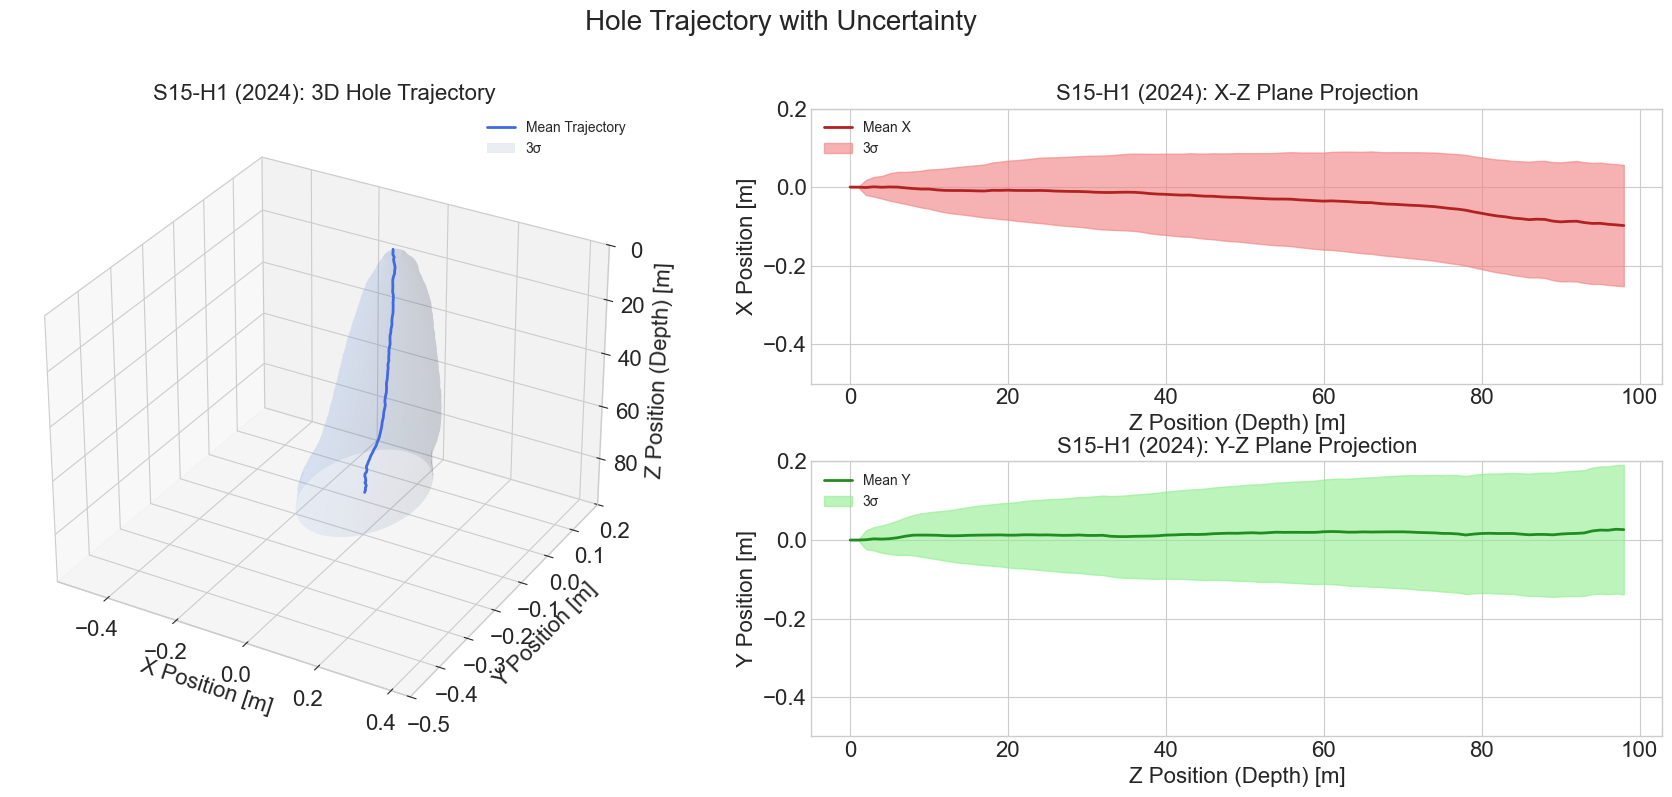

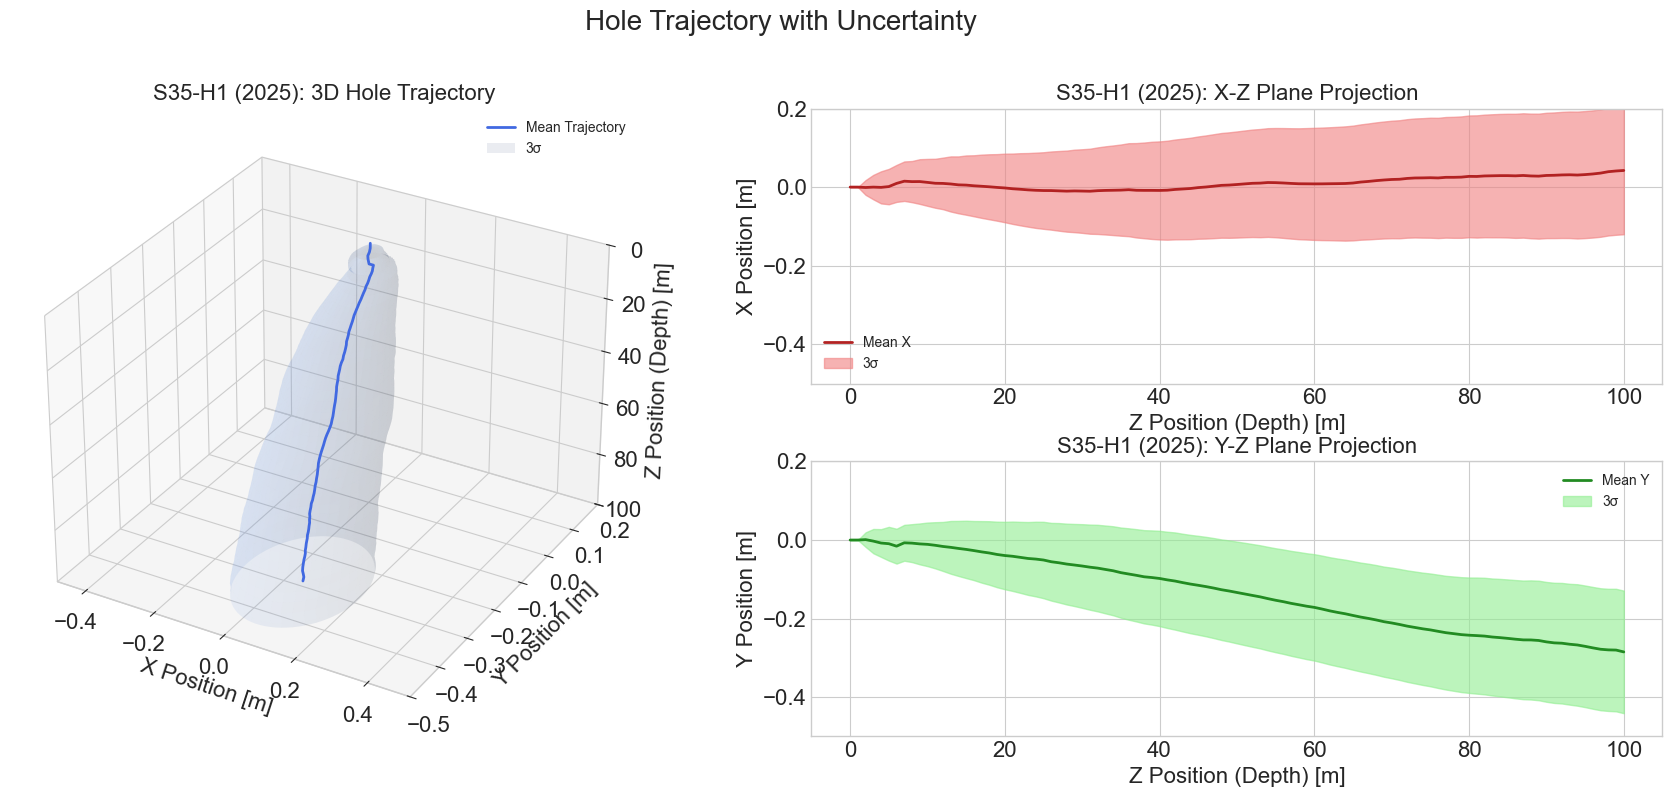

In [16]:
#fig, axes = plt.subplots(1, 3)
display_max = 0
index = [1,3]
print(label)
for i, df,l in zip(index, dataset,label):
    df = dataset[i]
    d = df[(df["[PLC]WIRESPOOLEDOUT"] > 2)]
    l = label[i].replace(", no ", "").replace("isopropanol", "").replace(", ", "")
    print(l)
    
    # Plot a 3D trajectory for the hole
    df_up = df[(df['[PLC]WIRESPOOLEDOUT'].diff() < 0) | (df["[PLC]CABLESPEED"].abs() < 0.1) & (df['cutting']==0)].dropna()
    
    dz = 1.0
    mean_angles_x, std_dev_angles_x, angle_bin_sizes = calc_binned_angles(df_up, "hole_pitch", dz=dz)
    mean_angles_y, std_dev_angles_y, _= calc_binned_angles(df_up, "hole_roll", dz=dz)
    
    z_coords, x_mean, x_std, y_mean, y_std = calculate_trajectory_3d(
        mean_angles_x, std_dev_angles_x,
        mean_angles_y, std_dev_angles_y,
        dz=dz
    )
    fig, ax = plot_trajectory_3d(z_coords, x_mean, x_std, y_mean, y_std)
    for ia,a in enumerate(ax):
        print(ia,a)
        a.tick_params(axis='both', labelsize=16)
        a.set_ylabel(a.get_ylabel(), fontsize=16)
        a.set_ylim(-0.5,0.2)
        a.set_xlabel(a.get_xlabel(), fontsize=16)
        if (ia==0):
            a.set_zlabel(a.get_zlabel(), fontsize=16)
        #a.set_legend(a.get_legend(), fontsize=14)
        a.set_title("%s: %s"% (l, a.get_title()), fontsize=16)
    plt.savefig("paper_plots/%s_hole-inclination.pdf" % l)
